In [26]:
import numpy as np
from matplotlib import pyplot as plt
import nibabel as nb
from scipy.ndimage import gaussian_filter
from scipy.ndimage import distance_transform_edt
from glob import glob
import sys
import os
sys.path.append('../')
# from slice_structure_identification_functions import compute_signed_distance_weight as compute_signed_distance_weight
# from slice_structure_identification_functions import compute_signed_distance_weight_filled as compute_signed_distance_weight_filled
from slice_registration_functions import apply_coordinate_mapping_2d, compose_coordinate_mappings_2d

In [ ]:


#import nighres as nr
#import nibabel as nib

root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
source_img = os.path.join(root_dir,"zefir_0038__Image_25_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz")

# source_data = nib.load(source_img).get_fdata()

mapping_img = os.path.join(root_dir,"init_translation_slice_0038/zefir_0038__Image_25_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
comparison_img = os.path.join(root_dir,"zefir_0038__Image_25_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-def0.nii.gz")

mapping_img2 = os.path.join(root_dir,"zefir_0038__Image_25_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
comparison_img2 = os.path.join(root_dir,"zefir_0038__Image_25_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-def0.nii.gz")

# mapping_data = nib.load(mapping_img).get_fdata()

inverse_mapping_img = os.path.join(root_dir,"init_translation_slice_0038/zefir_0038__Image_25_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-invmap.nii.gz")


deform = os.path.join(root_dir,"zefir_0038__Image_25_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-def0.nii.gz")
# deform_data = nib.load(deform).get_fdata()


# nr.registration.apply_coordinate_mappings(source_data, mapping_data, output_dir="/data/neuralabc/johmat/phase_ml/tmp/reg_test_output")



In [39]:
c_map = compose_coordinate_mappings_2d(nb.load(mapping_img), nb.load(mapping_img2))
res2 = apply_coordinate_mapping_2d(nb.load(source_img), c_map)
plt.figure(figsize=(20,20))
plt.subplot(1,2,1)
plt.imshow(nb.load(comparison_img2).get_fdata())
plt.subplot(1,2,2)
plt.imshow(nb.load(comparison_img2).get_fdata()-res2.get_fdata()) 

FileNotFoundError: No such file or no access: '/tmp/zefir_sliceReg_optimized_v2_rescale_40/zefir_0038__Image_25_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_win12_syn_4_ants-map.nii.gz'

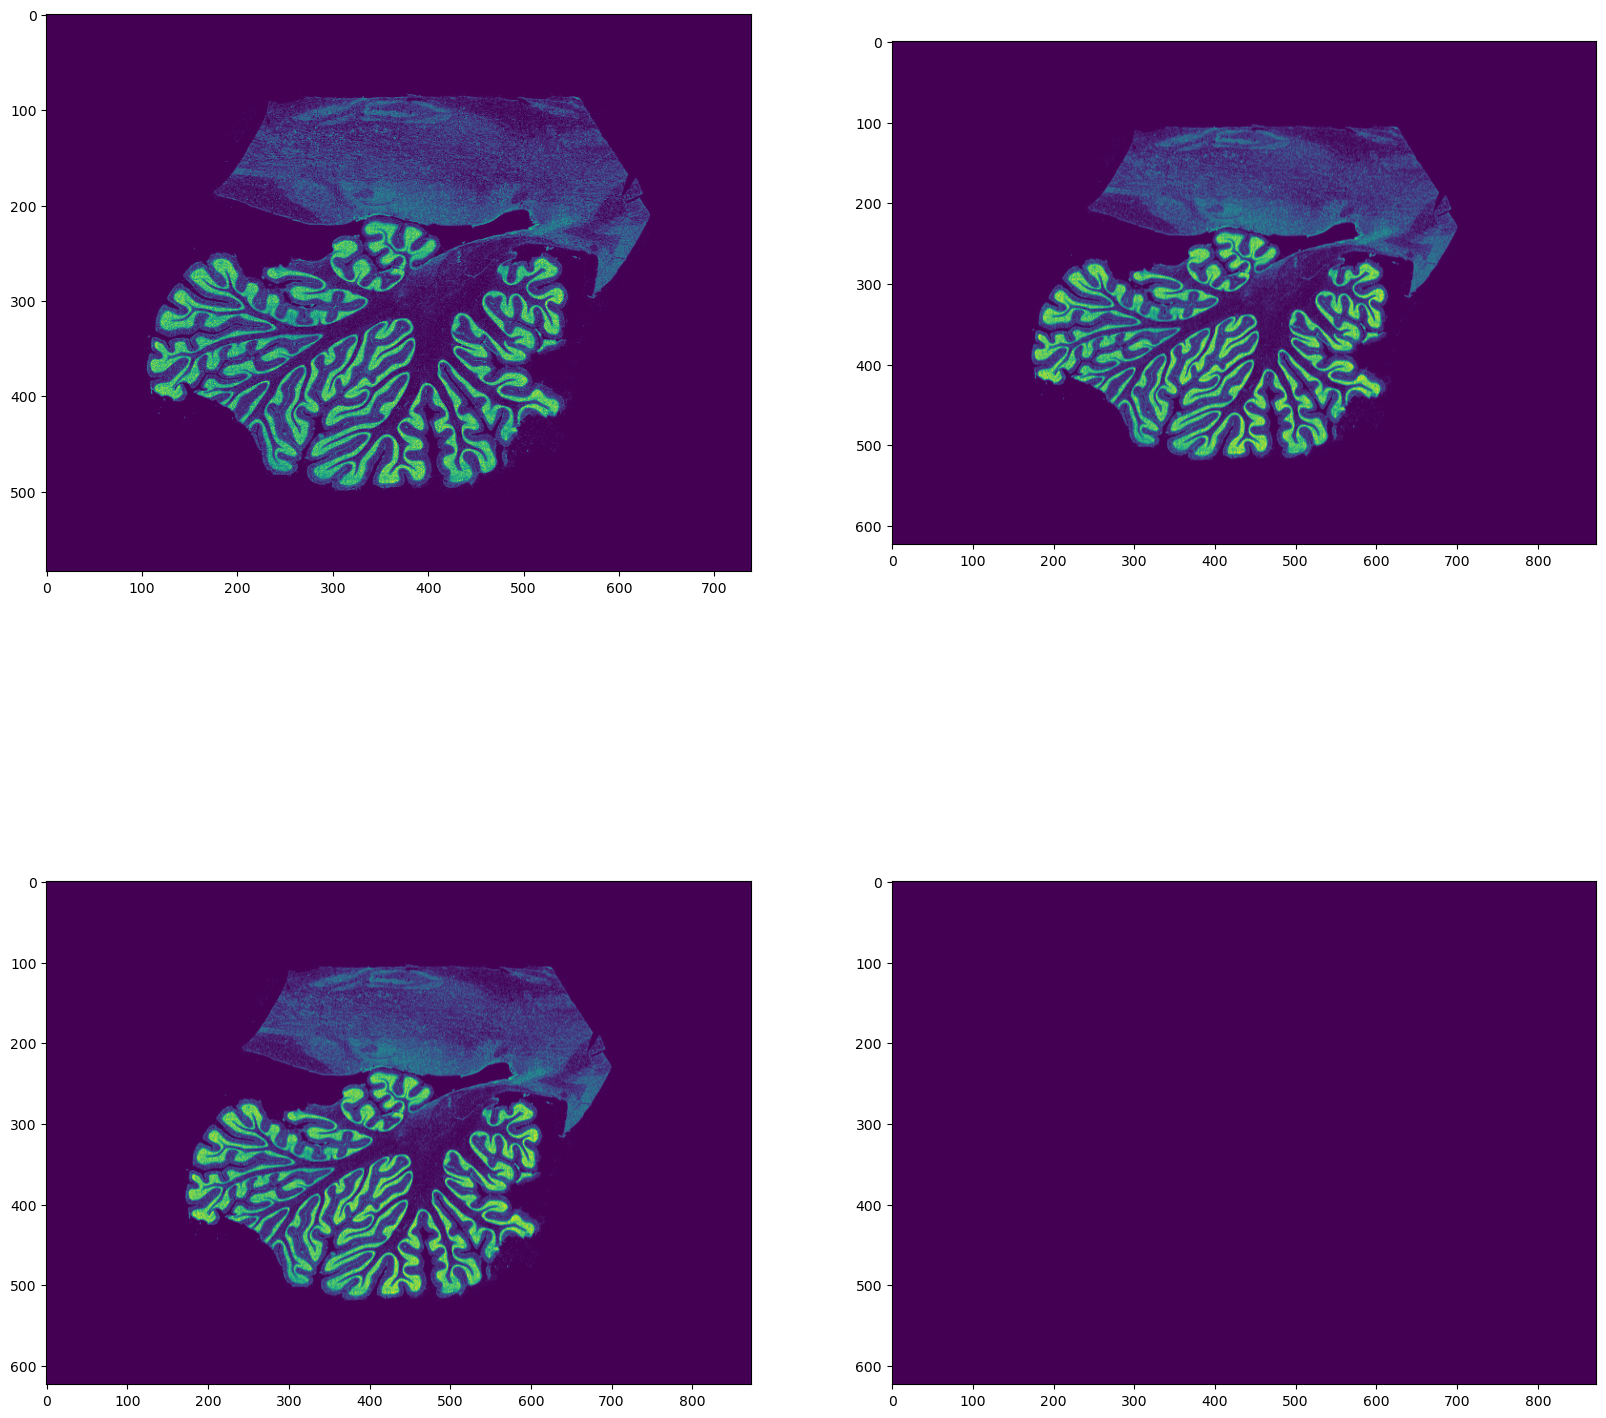

In [ ]:
res = apply_coordinate_mapping_2d(nb.load(source_img), nb.load(mapping_img))
src_d = nb.load(source_img).get_fdata()
cmp_d = nb.load(comparison_img).get_fdata()
plt.figure(figsize=(20,20))
plt.subplot(2,2,1)
plt.imshow(src_d)
plt.subplot(2,2,2)
plt.imshow(res.get_fdata())
plt.subplot(2,2,3)
plt.imshow(cmp_d)
plt.subplot(2,2,4)
plt.imshow(res.get_fdata()-cmp_d)